In [1]:
from stormpy import export_to_drn
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from verimon.logger import setup_logging

setup_logging()

In [2]:
from verimon import loaders
from random import randrange
from math import sqrt


mc_sl_u_nxn = "../tests/snake_ladder/mc_u_nxn.pm"

n, ladders, snakes = loaders.random_snl_board(4**2)
# n, ladders, snakes = (25, {17: 19, 9: 15, 8: 15, 6: 10, 14: 21}, {23: 8, 22: 20, 8: 1, 18: 2, 12: 2})
print(n, ladders, snakes)

# Random snakes and ladders
# mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n, ladders, snakes)

milton_snakes = {98: 76, 95: 75, 93: 73, 87: 24, 64: 60, 62: 19, 55: 53, 49: 11, 47: 26, 16: 6}
milton_ladders = {1: 38, 4: 14, 9: 31, 28: 64, 40: 42, 36: 44, 51: 67, 71: 91, 80: 100}
mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n := 10**2, ladders:=milton_ladders, snakes:=milton_snakes)

16 {4: 11, 7: 7, 2: 5} {11: 2, 12: 4, 14: 3}


In [3]:
from stormvogel.mapping import stormpy_to_stormvogel
from stormvogel.show import show
import stormvogel

stormvogel.communication_server.enable_server = False

mc_sv = stormpy_to_stormvogel(mc)
if mc_sv is None:
    raise Exception("boom")
loaders._add_valuation_to_sv_labels(mc, mc_sv)
# show(mc_sv)

Using matplotlib backend: module://matplotlib_inline.backend_inline


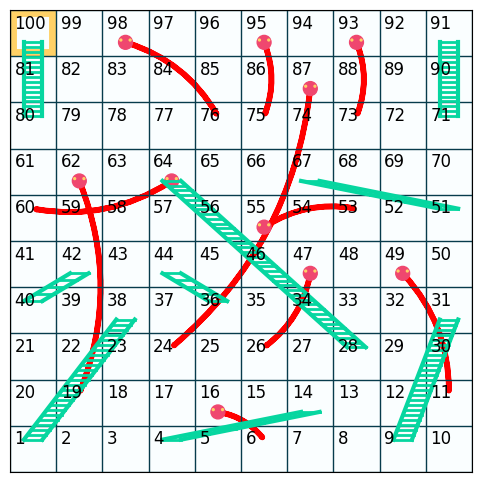

In [4]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

player_path = [(0, [])]

goal_squares = [next(int(l[5:-1]) for l in state.labels if l.startswith("[pos")) 
                for state in mc_sv.states.values() 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())

In [ ]:
from aalpy import run_Lstar, Dfa
from verimon.MonitorLearning import FilteringSUL, VerimonEqOracle, run_verimon

setup_logging()


threshold = 0.4
fp_slack = 0.3
fn_slack = 0.05
horizon = 14
relative_error = 0.1
spec = 'Pmax=? [F<3 "good" ]'

alphabet = ["init", "normal", "snake", "ladder"]

learned_monitor, info = run_verimon(
    mc,
    alphabet,
    "init",
    spec,
    "good",
    threshold,
    horizon,
    relative_error,
    True,
    fp_slack,
    fn_slack,
    expr_man,
    True,
    100,
    100,
)

DEBUG:2024-12-03 10:35:36,448 - (0.00s) - MonitorLearning.py(__init__) - Filtering SUL is using the following risk function: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.08333333333333333, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 1.0, 0.0, 0.0, 0.08333333333333333, 0.0, 0.25, 0.0, 0.25, 0.25, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.027777777777777776, 0.0, 0.25, 0.027777777777777776, 0.05555555555555555] 
Hypothesis 1: 1 states.
INFO:2024-12-03 10:35:36,449 - (0.00s) - MonitorLearning.py(find_cex) - Finding counterexample for hypothesis with 1 states 
DEBUG:2024-12-03 10:35:36,449 - (0.00

In [7]:
from verimon.loaders import aalpy_dfa_to_stormvogel
from verimon.transformations import simulator_unroll, prune_monitor
from verimon.algs import complement_model

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
# show(mon_cycl)
# complement_model(mon_cycl, "accepting")
mon = simulator_unroll(mon_cycl, horizon)
prune_monitor(mon)
print(len(mon.states))
show(mon)

215


In [ ]:
from verimon.loaders import aalpy_dfa_to_stormvogel
from verimon.verify import *

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
export_to_drn(stormvogel_to_stormpy(mon_cycl), "monitor.drn")
result_goal, trace, assignment, product = false_positive(mc, mon_cycl, horizon, expr_man, options = {"good_spec": spec, "use_risk": True})

DEBUG:2024-12-03 11:31:02,494 - (18.17s) - verify.py(_verify_helper) - Building model 
Write to file monitor.drn.
DEBUG:2024-12-03 11:31:02,500 - (0.01s) - verify.py(_verify_helper) - Unrolling done 
INFO:2024-12-03 11:31:02,511 - (0.01s) - generator.py(set_risk) - Risk function becomes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.08333333333333333, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 1.0, 0.0, 0.0, 0.08333333333333333, 0.0, 0.25, 0.0, 0.25, 0.25, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.027777777777777776, 0.0, 0.25, 0.027777777777777776, 0.05555555555555555] 


DEBUG:2024-12-03 11:31:02,511 - (0.00s) - verify.py(_verify_helper) - Apply risk done 
Kept 9090 out of 11883 rows.
DEBUG:2024-12-03 11:31:02,949 - (0.44s) - verify.py(_verify_helper) - creating product done 
DEBUG:2024-12-03 11:31:02,949 - (0.00s) - verify.py(_verify_helper) - Finding specified trace 


INFO:paynt.quotient.pomdp:constructed POMDP having 21 observations.


2024-12-03 11:31:02,996 - pomdp.py - constructed POMDP having 21 observations.


DEBUG:paynt.quotient.pomdp:unfolding 1-FSC template into POMDP...


...

INFO:paynt.synthesizer.synthesizer:A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=normal, A(13,0)=normal, A(14,0)=normal, A(15,0)=normal, A(16,0)=normal, A(17,0)=ladder, A(18,0)=normal, A(20,0)=end


2024-12-03 11:40:28,224 - synthesizer.py - A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=normal, A(13,0)=normal, A(14,0)=normal, A(15,0)=normal, A(16,0)=normal, A(17,0)=ladder, A(18,0)=normal, A(20,0)=end


INFO:paynt.synthesizer.synthesizer:double-checking specification satisfiability:  : 0.5003443123639507


2024-12-03 11:40:28,226 - synthesizer.py - double-checking specification satisfiability:  : 0.5003443123639507
INFO:2024-12-03 11:40:28,226 - (565.28s) - generator.py(check_paynt_prop) - counterexample found: A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=normal, A(13,0)=normal, A(14,0)=normal, A(15,0)=normal, A(16,0)=normal, A(17,0)=ladder, A(18,0)=normal, A(20,0)=end 
INFO:2024-12-03 11:40:28,226 - (0.00s) - generator.py(check_paynt_prop) - --------------------
Synthesis summary:
optimality objective: Pmax=? [F "stop"] [eps = 0.1]

method: AR, synthesis time: 565.14 s
number of holes: 18, family size: 1e8, quotient: 3392 states / 9090 actions
explored: 100 %
MDP stats: avg MDP size: 226, iterations: 9572

optimum: 0.500344
--------------------
 
INFO:2024-12-03 11:40:28,228 - (0.00s) - verify.py(_verify_helper) - Found trace: ['ladder', 'normal', 'ladder', 'normal', 'norma

: 

Using matplotlib backend: module://matplotlib_inline.backend_inline
INFO:2024-11-26 14:13:48,016 - (0.11s) - generator.py - s2, obs=2, labels=init 


INFO:2024-11-26 14:13:53,296 - (5.28s) - generator.py - --[2, ladder]-->	s6, val={_mc71: 1,_mon70: 2,pos: 1}, labels=
--[3, normal]-->	s16, val={_mc71: 7,_mon70: 5,pos: 38}, labels=
--[4, normal]-->	s34, val={_mc71: 16,_mon70: 9,pos: 41}, labels=
--[5, normal]-->	s82, val={_mc71: 30,_mon70: 16,pos: 46}, labels=
--[6, ladder]-->	s165, val={_mc71: 47,_mon70: 28,pos: 51}, labels=
--[7, normal]-->	s301, val={_mc71: 57,_mon70: 45,pos: 67}, labels=
--[8, ladder]-->	s483, val={_mc71: 68,_mon70: 65,pos: 71}, labels=
--[9, normal]-->	s615, val={_mc71: 77,_mon70: 88,pos: 91}, labels=
--[10, normal]-->	s730, val={_mc71: 88,_mon70: 114,pos: 96}, labels=
--[11, normal]-->	s930, val={_mc71: 98,_mon70: 143,pos: 99}, labels=
--[13, normal]-->	s1199, val={_mc71: 89,_mon70: 174,pos: 97}, labels=
--[16, end]-->	s1, val={_mc71: -1,_mon70: -1,pos: -1}, labels=stop 
INFO:2024-11-26 14:13:53,297 - (0.00s) - generator.py - it took 4241 tries until the goal was reached 


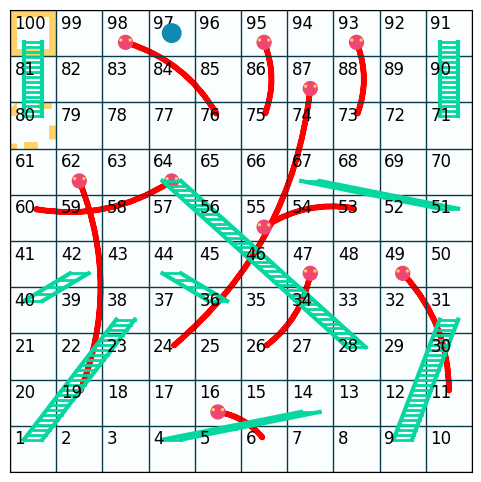

In [ ]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

# player_path = [(0, [])]
poss = product.simulate_paynt_assignment(assignment, 100000)
player_path = poss

goal_squares = [int(str(state.valuations)[5:-1]) 
                for state in product.mc.states 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())